# Lista de Exercício 3
### Introdução à Visão Computacional (SEL0339/SEL5886)

**Instruções:**

 1. Esta lista consiste em 3 exercícios.
 1. Deve-se colocar comentários nos códigos desenvolvidos.
 1. As perguntas devem ser respondidas também como comentários no arquivo.
 1. Colocar seu nome e número USP abaixo.
 1. Quaisquer problemas na execução das listas, entrar em contato com os monitores.
 1. Depois de terminado os exercícios, deve ser gerado um arquivo **extensão .ipynb** para ser enviado ao professor pelo E-DISCIPLINAS da disciplina até a data máxima de entrega.
 1. Caso não seja enviado, o aluno ficará sem nota.

**Objetivos:**

Ao final desta prática, espera-se que o aluno seja capaz de:

* compreender o funcionamento de um perceptron;
* calcular manualmente a saída de um perceptron;
* implementar um perceptron utilizando apenas NumPy;
* treinar um perceptron iterativamente;
* compreender intuitivamente o gradiente descendente;
* visualizar graficamente o processo de otimização;



 <table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/LAVI-Disciplinas/SEL0339-SEL5886_2026/blob/main/praticas/Lista_de_Exercicio_3.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Executar no Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/blob/main/praticas/Lista_de_Exercicio_3.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />Ver codigo fonte no GitHub</a>
  </td>
</table>


`Nome: `

`Número USP:`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.mplot3d import Axes3D

## 1) Entendendo o Perceptron

O **perceptron** é um modelo simples de neurônio artificial. Ele recebe um conjunto de entradas, multiplica cada entrada por um peso, soma os resultados e aplica uma função de ativação.

Para duas entradas, podemos representar o perceptron por:

$$
z = w_1x_1 + w_2x_2 + b
$$

A saída do perceptron é definida por uma função de ativação degrau:

$$
\hat{y} =
\begin{cases}
1, & \text{se } z \geq 0 \\
0, & \text{se } z < 0
\end{cases}
$$

onde:

- $x_1$ e $x_2$ são as **entradas**;
- $w_1$ e $w_2$ são os **pesos** associados às entradas;
- $b$ é o **bias**;
- $z$ é o resultado da **combinação linear** das entradas;
- $\hat{y}$ é a **saída prevista pelo perceptron**.


### 1.1) Classificando entre Gato e Cachorro:

Imagine que você tem informações de comprimento e largura de animais medidos e quer classificá-lo entre gato e cachorro. Se a saida é 0, você atribui a gato, se a saída é 1, atribui a cachorro.

Além disso, considere que alguém ja treinou um perceptrom para você com os seguintes pesos e bias:
$$
w_1 = 0.5, \qquad w_2 = -0.2
$$

$$
b = 0.1
$$

Suas amostras são:

Animal 1:
$$
Comprimento = 2, \qquad Largura = 3
$$

Animal 2:
$$
Comprimento = 1, \qquad Largura = 5
$$

Animal 3:
$$
Comprimento = 3, \qquad Largura = 4.6
$$



1. Escreva um código simples que implemente o perceptrom com os pesos bias dados e que retorne a classe para os animais dados.

**Perguntas:**

1. Qual a Classe dos animais 1 2 e 3 ?
2. Reimplemente o Perceptron alterando os pesos, ou seja, considerando que ele foi re-treinado. w1 = 1 e w2 = 0.5. As classes mudaram?

In [2]:
## -- Seu código começa AQUI -- ##

# Função que implementa o perceptron para classificar os animais
def gato_cachorro(x1, x2):
    # Pesos e bias pré-definidos
    w1 = 0.5
    w2 = -0.2
    b = 0.1

    # Equação geral
    z = w1*x1 + w2*x2 + b

    # Função de ativação
    # 1 representa cachorro e 0 representa gato
    if z >= 0:
        return 1
    else:
        return 0


# Vetor contendo as características dos três animais:
# [comprimento, largura]
animais = np.array([[2, 3], [1, 5], [3, 4.6]])

# Percorre cada animal e realiza sua classificação
i = 1
for animal in animais:
    classe = gato_cachorro(animal[0], animal[1])

    # Converte a saída numérica do perceptron para a classe correspondente
    if classe:
        print(f"Animal {i} é um cachorro")
    else:
        print(f"Animal {i} é um gato")

    i += 1


# Parte 2: classificação utilizando os novos pesos
def gato_cachorro2(x1, x2):
    # Novos pesos definidos após o re-treinamento do perceptron
    w1 = 1
    w2 = 0.5
    b = 0.1

    # Calcula a nova combinação linear
    z = w1*x1 + w2*x2 + b

    # Aplica novamente a função de ativação degrau
    if z >= 0:
        return 1
    else:
        return 0


print("\nRecalculando com novos pesos:\n")

# Classifica novamente os mesmos animais utilizando os novos pesos
i = 1
for animal in animais:
    classe = gato_cachorro2(animal[0], animal[1])

    if classe:
        print(f"Animal {i} é um cachorro")
    else:
        print(f"Animal {i} é um gato")

    i += 1

## -- Seu código termina AQUI -- ##
#Comentários:
# O perceptron foi implementado utilizando os pesos e o bias fornecidos no enunciado.
# A saída 0 representa gato e a saída 1 representa cachorro. Com os pesos
# iniciais, os animais 1 e 3 foram classificados como cachorros e o animal 2
# como gato.
# Após o re-treinamento, utilizando w1 = 1 e w2 = 0.5, o animal 2 mudou de
# classificação e passou a ser classificado como cachorro, enquanto os animais
# 1 e 3 permaneceram como cachorros.

Animal 1 é um cachorro
Animal 2 é um gato
Animal 3 é um cachorro

Recalculando com novos pesos:

Animal 1 é um cachorro
Animal 2 é um cachorro
Animal 3 é um cachorro


## 2) Treinando um Perceptron

Normalmente, um perceptron é treinado utilizando um conjunto de exemplos. Para cada exemplo, fornecemos ao modelo os **valores das entradas** e o **label (rótulo) correspondente**, que representa a classe correta daquela amostra.

Utilizando as mesmas variáveis apresentadas anteriormente, cada exemplo possui duas entradas, $x_1$ e $x_2$, e um label $y$:

$$
(x_1, x_2) \rightarrow y
$$

Por exemplo, podemos fornecer ao perceptron:

$$
x_1 = 2, \qquad x_2 = 3
$$

e informar que a classe correta para esse exemplo é:

$$
y = 1
$$

O perceptron utiliza os valores de $x_1$ e $x_2$, juntamente com seus pesos $w_1$, $w_2$ e o bias $b$, para calcular sua previsão:

$$
z = w_1x_1 + w_2x_2 + b
$$

e então:

$$
\hat{y} =
\begin{cases}
1, & \text{se } z \geq 0 \\
0, & \text{se } z < 0
\end{cases}
$$

A previsão $\hat{y}$ é então comparada com o label verdadeiro $y$. Se a previsão estiver incorreta, os pesos e o bias são atualizados para tentar reduzir esse erro.

Assim, durante o treinamento, fornecemos repetidamente ao perceptron diferentes exemplos contendo:

* **Entradas:** $x_1$ e $x_2$;
* **Label verdadeiro:** $y$;

O objetivo do treinamento é encontrar valores adequados para os pesos e para o bias, de forma que o perceptron consiga produzir corretamente os labels para os exemplos apresentados.


Dessa forma, vamos utilizar a classe Perceptron implementada abaixo para treinar um perceptron em três problemas lógicos clássicos:

- **OR**
- **AND**
- **XOR**

Em todos os casos, utilizaremos as mesmas entradas:

$$
X =
\begin{bmatrix}
0 & 0 \\
0 & 1 \\
1 & 0 \\
1 & 1
\end{bmatrix}
$$

O que muda entre os problemas são os **labels**, que indicam a saída correta para cada combinação de entradas.

### 2.1) Problema OR

Para a operação **OR**, a saída será 1 quando pelo menos uma das entradas for igual a 1:

| $x_1$ | $x_2$ | $y$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

---

### 2.2) Problema AND

Para a operação **AND**, a saída será 1 somente quando as duas entradas forem iguais a 1:

| $x_1$ | $x_2$ | $y$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |


---

### 2.3) Problema XOR

Para a operação **XOR**, a saída será 1 quando as duas entradas forem diferentes:

| $x_1$ | $x_2$ | $y$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

# Manual rápido — Perceptron

O `Perceptron` foi implementado abaixo como uma classe, que segue a seguinte lógica:

### 1. Criar uma instância

Uma instância é um objeto criado a partir da classe:

```python
perceptron = Perceptron(learning_rate=0.1, epochs=10)
```

* `learning_rate`: controla o tamanho da atualização dos pesos.
* `epochs`: número máximo de ciclos de treinamento.

### 2. Preparar os dados

`X` contém as entradas e `y` as classes corretas:

```python
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])
```

### 3. Treinar

O método `fit()` aprende os pesos e o `bias`:

```python
perceptron.fit(X, y)
```

### 4. Predizer

Para as amostras X:

```python
predictions = perceptron.predict(X)
```

### 5. Funções da classe

| Função           | Uso                    |
| ---------------- | ---------------------- |
| `fit(X, y)`      | Treina o modelo        |
| `predict(X)`     | Prediz várias amostras |
| `predict_one(x)` | Prediz uma amostra     |

**Fluxo básico:**

```python
perceptron = Perceptron(learning_rate=0.1, epochs=10)
perceptron.fit(X, y)
predictions = perceptron.predict(X)
```
####Esse mesmo fluxograma normalmente é usado em bilbiotecas bem difundidas como **scikit-learn**.


**Tarefa:** utilizando a classe `Perceptron` implementada abaixo:


1. Crie o conjunto de dados `X`.
2. Crie o vetor de labels `y_and, y_or, y_xor ...`.
3. Crie uma instância da classe `Perceptron`. Não se esqueça de definir valores padrão para a taxa de aprendizado e número de épocas. Sugestão: learning_rate=0.1, epochs=10
4. Treine o modelo utilizando `.fit()`.
5. Utilize `.predict()` para realizar as previsões.
6. Compare as previsões com os labels verdadeiros.
7. Plote os valores das duas classes em um gráfico de dispersão.



**Pergunta:** o perceptron conseguiu aprender corretamente os três problemas? Compare os resultados obtidos para OR, AND e XOR e explique as diferenças observadas. Pense e pesquise sobre o que é um problema linearmente separável.

Use o código abaixo como base:

```python
# Dados de entrada
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Labels do problema OR
y_or = ...

# Crie o perceptron
modelo_or = ...

# Treine o modelo
...

# Realize as previsões
predicoes_or = ...

print("Labels verdadeiros:", y_or)
print("Previsões:", predicoes_or)

#Plote as predições
plt.scatter(range(len(y)), y, label="Real")
plt.scatter(range(len(predicoes)), predicoes, marker="x", label="Predito")

plt.xlabel("Amostra")
plt.ylabel("Classe")
plt.title("Valores reais vs. preditos")
plt.legend()
plt.show()

#### **Atenção**: o código abaixo implementa a classe do Perceptron. EXECUTE-O!

In [10]:
class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=10):
        self.learning_rate = learning_rate
        self.epochs = epochs

        # Inicialização dos pesos e bias
        self.weights = None
        self.bias = 0

    def activation(self, z):
        """
        Função de ativação degrau.
        """
        if z >= 0:
            return 1
        else:
            return 0

    def predict_one(self, x):
        """
        Realiza a previsão para uma única amostra.
        """

        z = np.dot(x, self.weights) + self.bias

        return self.activation(z)

    def predict(self, X):
        """
        Realiza previsões para todas as amostras.
        """

        predictions = []

        for x in X:
            predictions.append(self.predict_one(x))

        return np.array(predictions)

    def fit(self, X, y):
        """
        Treina o perceptron utilizando a regra de atualização
        dos pesos.
        """

        # Inicializa os pesos com zero
        self.weights = np.zeros(X.shape[1])

        self.bias = 0

        # Repetição do treinamento
        for epoch in range(self.epochs):

            errors = 0

            # Percorre todas as amostras
            for x, target in zip(X, y):

                # Faz a previsão
                prediction = self.predict_one(x)

                # Calcula o erro
                error = target - prediction

                # Atualiza os pesos
                self.weights += self.learning_rate * error * x

                # Atualiza o bias
                self.bias += self.learning_rate * error

                # Conta os erros
                if error != 0:
                    errors += 1

            print(
                f"Época {epoch + 1}: "
                f"{errors} erro(s)"
            )

            # Se não houver erros, o treinamento pode terminar
            if errors == 0:
                break

        return self

Época 1: 2 erro(s)
Época 2: 2 erro(s)
Época 3: 1 erro(s)
Época 4: 0 erro(s)
OR
Labels verdadeiros: [0 1 1 1]
Previsões: [0 1 1 1]


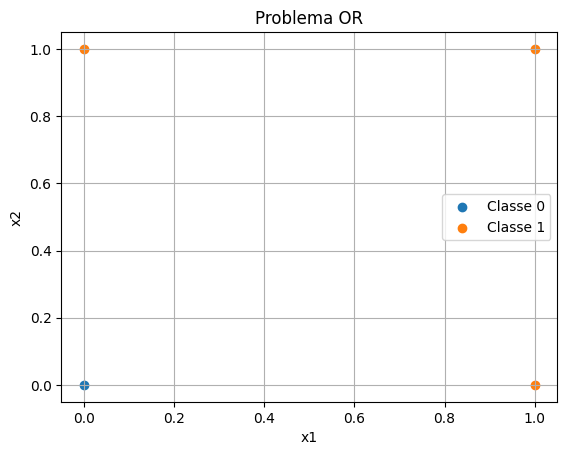

In [18]:
# Dados de entrada
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Labels do problema OR
y_or = np.array([0, 1, 1, 1])

# Crie o perceptron
modelo_or = Perceptron(learning_rate=0.1, epochs=10)

# Treine o modelo
modelo_or.fit(X, y_or)

# Realize as previsões
predicoes_or = modelo_or.predict(X)

print("OR")
print("Labels verdadeiros:", y_or)
print("Previsões:", predicoes_or)

# Plote os valores das duas classes
plt.scatter(X[y_or == 0, 0], X[y_or == 0, 1], label="Classe 0")
plt.scatter(X[y_or == 1, 0], X[y_or == 1, 1], label="Classe 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Problema OR")
plt.legend()
plt.grid()
plt.show()

# Comentários
# O perceptron conseguiu aprender corretamente o problema OR,
# pois as previsões foram iguais aos labels verdadeiros.
# O problema OR é linearmente separável, pois é possível encontrar
# uma única reta que separa as classes 0 e 1.

Época 1: 2 erro(s)
Época 2: 3 erro(s)
Época 3: 3 erro(s)
Época 4: 0 erro(s)
AND
Labels verdadeiros: [0 0 0 1]
Previsões: [0 0 0 1]


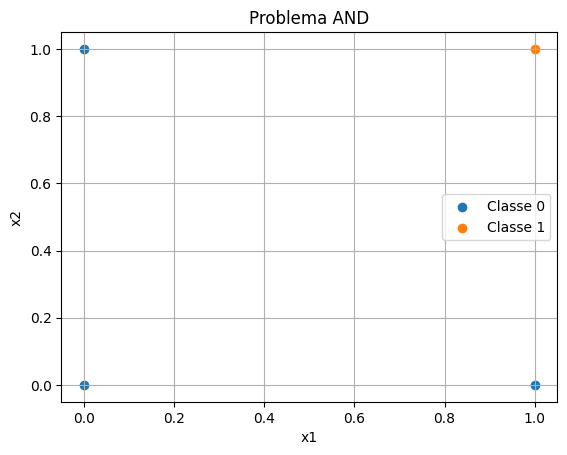

In [15]:
## -- Seu código começa AQUI -- ##

# Dados de entrada
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Labels do problema AND
y_and = np.array([0, 0, 0, 1])

# Crie o perceptron
modelo_and = Perceptron(learning_rate=0.1, epochs=10)

# Treine o modelo
modelo_and.fit(X, y_and)

# Realize as previsões
predicoes_and = modelo_and.predict(X)

print("AND")
print("Labels verdadeiros:", y_and)
print("Previsões:", predicoes_and)

# Plote os valores das duas classes
plt.scatter(X[y_and == 0, 0], X[y_and == 0, 1], label="Classe 0")
plt.scatter(X[y_and == 1, 0], X[y_and == 1, 1], label="Classe 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Problema AND")
plt.legend()
plt.grid()
plt.show()

# Comentários:
# O perceptron também conseguiu aprender corretamente o problema AND,
# pois as previsões foram iguais aos labels verdadeiros.
# Assim como o OR, o problema AND é linearmente separável, sendo possível
# separar as duas classes utilizando uma única reta.


Época 1: 3 erro(s)
Época 2: 3 erro(s)
Época 3: 4 erro(s)
Época 4: 4 erro(s)
Época 5: 4 erro(s)
Época 6: 4 erro(s)
Época 7: 4 erro(s)
Época 8: 4 erro(s)
Época 9: 4 erro(s)
Época 10: 4 erro(s)
XOR
Labels verdadeiros: [0 1 1 0]
Previsões: [1 1 0 0]


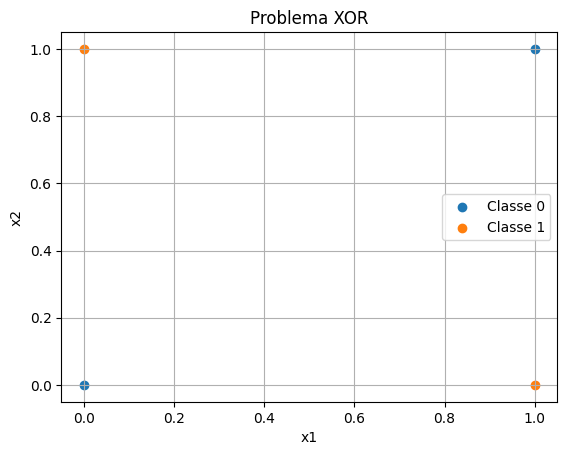

In [16]:
## -- Seu código começa AQUI -- ##

# Labels do problema XOR
y_xor = np.array([0, 1, 1, 0])

# Crie o perceptron
modelo_xor = Perceptron(learning_rate=0.1, epochs=10)

# Treine o modelo
modelo_xor.fit(X, y_xor)

# Realize as previsões
predicoes_xor = modelo_xor.predict(X)

print("XOR")
print("Labels verdadeiros:", y_xor)
print("Previsões:", predicoes_xor)

# Plote os valores das duas classes
plt.scatter(X[y_xor == 0, 0], X[y_xor == 0, 1], label="Classe 0")
plt.scatter(X[y_xor == 1, 0], X[y_xor == 1, 1], label="Classe 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Problema XOR")
plt.legend()
plt.grid()
plt.show()

#Comentários:
# O perceptron não conseguiu aprender corretamente o problema XOR,
# pois as previsões não foram iguais aos labels verdadeiros.
# Isso acontece porque o XOR não é linearmente separável ou seja, não é possível
# encontrar uma única reta que separe corretamente as duas classes.
# Por isso, um perceptron de uma camada não consegue aprender o XOR.



## 3) Diferenciação automática e Gradiente Descendente

Durante o treinamento de modelos de aprendizado de máquina, precisamos encontrar os valores dos parâmetros que minimizem uma determinada função de custo ou de perda (*loss function*). Essa função de perda é responsável por medir o tamanho do erro cometido pelo *Perceptron* em sua previsão.

Para realizar esse ajuste, a principal ferramenta utilizada é o **gradiente descendente**, um algoritmo de otimização que o modelo usa para aprender e corrigir seus erros. A partir de um ponto inicial, ele dá pequenos passos no sentido oposto ao gradiente da função até encontrar o seu ponto de mínimo.

Para uma função de uma variável $f(x)$, a atualização pode ser escrita como:

$$
x_{novo} = x_{atual} - \eta \frac{df}{dx}
$$

onde $\eta$ é a **taxa de aprendizado** (*learning rate*), que define o tamanho do passo que o *Perceptron* dá a cada atualização do Gradiente Descendente.

### Diferenciação automática

Para utilizar o gradiente descendente, precisamos calcular as derivadas da função. Em problemas simples, podemos calcular essas derivadas manualmente. Entretanto, funções utilizadas em redes neurais podem ser muito mais complexas.

A **diferenciação automática** (*automatic differentiation*) permite calcular essas derivadas automaticamente a partir das operações realizadas durante o cálculo da função.

Bibliotecas como **PyTorch** e **TensorFlow** utilizam diferenciação automática para calcular gradientes durante o treinamento de redes neurais.

A ideia pode ser resumida como:

$$
\text{Função}
\rightarrow
\text{Diferenciação automática}
\rightarrow
\text{Gradiente}
\rightarrow
\text{Atualização}
$$




### 3.1) Gradiente descendente em uma dimensão

Considere a função:

$$
f(x) = x^2
$$

O objetivo é encontrar o valor de $x$ que minimiza essa função.

**Tarefa:**

Utilizando diferenciação automática:

1. Defina a função $f(x)=x^2$.
2. Escolha um valor inicial para $x$.
3. Defina uma taxa de aprendizado.
4. Calcule automaticamente o gradiente de $f(x)$ em relação a $x$.
5. Atualize $x$ utilizando o gradiente descendente.
6. Repita o processo por várias iterações.
7. Armazene os valores de $x$ encontrados durante o processo.
8. Plote a função $f(x)$ e os pontos percorridos pelo algoritmo até chegar ao mínimo.

O mínimo esperado ocorre em:

$$
x=0
$$

Use esse código como base:

```python
x = torch.tensor(5.0, requires_grad=True)

# Taxa de aprendizado
learning_rate = 0.1

# Número de iterações
epochs = 20

# Armazenar os valores visitados
history = []


for epoch in range(epochs):

    # Função f(x) = x²
    f = ..

    # Calcula automaticamente o gradiente
    f.backward()

    # Guarda o valor atual de x
    history.append(x.item())

    # Atualiza x
    with torch.no_grad():
        x -= learning_rate * x.grad

    # Zera o gradiente para a próxima iteração
    x.grad.zero_()


print("Valor final de x:", x.item())
print("Valor final de f(x):", f.item())
```

E para plotar os valores:
```python
# Valores para desenhar a função
x_values = np.linspace(-6, 6, 200) #
y_values = x_values**2

# Converte o histórico para um array
history = np.array(history)

# Plota a função f(x) = x²
plt.plot(x_values, y_values, label="f(x) = x²")

# Plota os pontos percorridos pelo gradiente descendente
plt.scatter(
)

# Destaca o ponto final
plt.scatter(
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradiente Descendente em uma Dimensão")
plt.legend()
plt.grid()

plt.show()
```

In [28]:
## -- Seu código começa AQUI -- ##

# Função f(x) = x²
def squared(x):
    return x * x

# Valor inicial de x
x = torch.tensor(5.0, requires_grad=True)

# Taxa de aprendizado
learning_rate = 0.1

# Número de iterações
epochs = 20

# Armazenar os valores visitados
history = []


for epoch in range(epochs):

    # Calcula f(x)
    f = squared(x)

    # Calcula automaticamente o gradiente
    f.backward()

    # Guarda o valor atual de x
    history.append(x.item())

    # Atualiza x
    with torch.no_grad():
        x -= learning_rate * x.grad

    # Zera o gradiente para a próxima iteração
    x.grad.zero_()


print("Valor final de x:", x.item())
print("Valor final de f(x):", f.item())



## -- Seu código termina AQUI -- ##

Valor final de x: 0.057646073400974274
Valor final de f(x): 0.005192296113818884


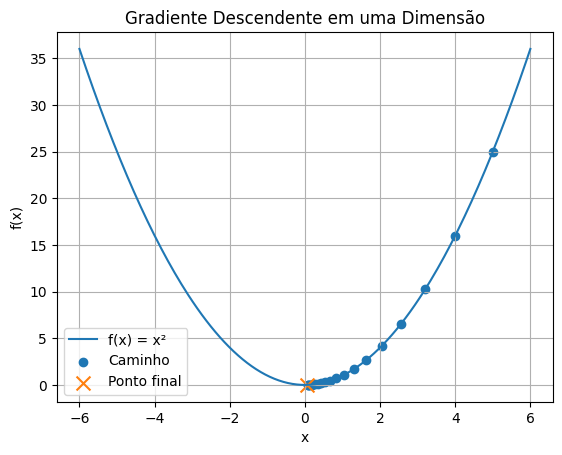

In [27]:
## -- Seu código começa AQUI -- ##
# Valores para desenhar a função
x_values = np.linspace(-6, 6, 200)
y_values = x_values**2

# Converte o histórico para um array
history = np.array(history)

# Plota a função f(x) = x²
plt.plot(x_values, y_values, label="f(x) = x²")

# Plota os pontos percorridos pelo gradiente descendente
plt.scatter(history, history**2, label="Caminho")

# Destaca o ponto final
plt.scatter(x.item(), x.item()**2, marker="x", s=100, label="Ponto final")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradiente Descendente em uma Dimensão")
plt.legend()
plt.grid()

plt.show()
## -- Seu código termina AQUI -- ##

### 3.2) Gradiente descendente em duas dimensões

Agora vamos trabalhar com uma função de duas variáveis:

$$
f(x,y) = x^2 + y^2
$$

Nesse caso, precisamos calcular o gradiente em relação às duas variáveis:

$$
\nabla f =
\begin{bmatrix}
\frac{\partial f}{\partial x}\\
\frac{\partial f}{\partial y}
\end{bmatrix}
$$

**Tarefa:**

Utilizando diferenciação automática:

1. Defina as variáveis $x$ e $y$.
2. Defina a função $f(x,y)=x^2+y^2$.
3. Escolha valores iniciais para $x$ e $y$.
4. Calcule automaticamente o gradiente em relação a $x$ e $y$.
5. Atualize as duas variáveis utilizando o gradiente descendente.
6. Repita o processo por várias iterações.
7. Armazene os pontos $(x,y)$ visitados.
8. Faça um gráfico 3D da função.
9. Plote sobre a superfície o caminho percorrido pelo gradiente descendente até chegar ao mínimo.

O mínimo esperado ocorre em:

$$
(x,y)=(0,0)
$$

Use esse código como base:
```python
# Valores iniciais
x = torch.tensor(5.0, requires_grad=True)
y = torch.tensor(4.0, requires_grad=True)

# Taxa de aprendizado
learning_rate = 0.1

# Número de iterações
epochs = 20

# Armazenar os pontos visitados
history = []


for epoch in range(epochs):

    # Função f(x,y) = x² + y²
    f = ...
    # Calcula automaticamente os gradientes
    f.backward()

    # Guarda o ponto atual
    history.append((x.item(), y.item()))

    # Atualize x utilizando x.grad
    # x = ...

    # Atualize y utilizando y.grad
    # y = ...

    # Zera os gradientes
    x.grad.zero_()
    y.grad.zero_()


print("x final:", x.item())
print("y final:", y.item())
print("f(x,y) final:", f.item())

```

E para plotar:
```python
# Cria uma grade de pontos
x_values = np.linspace(-6, 6, 100)
y_values = np.linspace(-6, 6, 100)

X_grid, Y_grid = np.meshgrid(x_values, y_values)

# Calcula a função em cada ponto
Z = X_grid**2 + Y_grid**2

# Converte o histórico
history = np.array(history)

# Cria o gráfico 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Plota a superfície
ax.plot_surface(
)

# Calcula os valores de f(x,y) dos pontos percorridos
Z_history = history[:, 0]**2 + history[:, 1]**2

# Plota o caminho do gradiente descendente
ax.plot(
)

# Destaca o ponto final
ax.scatter(
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

ax.set_title("Gradiente Descendente em Duas Dimensões")

ax.view_init(elev=40, azim=170)

plt.show()
```
### Perguntas

1. O algoritmo conseguiu chegar próximo do mínimo nos dois casos?
2. O que acontece quando a taxa de aprendizado é muito pequena?
3. O que acontece quando a taxa de aprendizado é muito grande?
4. Como esse processo de otimização está relacionado ao treinamento de uma rede neural?


In [29]:
## -- Seu código começa AQUI -- ##
## -- Seu código começa AQUI -- ##

# Valores iniciais
x = torch.tensor(5.0, requires_grad=True)
y = torch.tensor(4.0, requires_grad=True)

# Taxa de aprendizado
learning_rate = 0.1

# Número de iterações
epochs = 20

# Armazenar os pontos visitados
history = []


for epoch in range(epochs):

    # Função f(x,y) = x² + y²
    f = x**2 + y**2

    # Calcula automaticamente os gradientes
    f.backward()

    # Guarda o ponto atual
    history.append((x.item(), y.item()))

    # Atualiza x utilizando o gradiente
    with torch.no_grad():
        x -= learning_rate * x.grad

    # Atualiza y utilizando o gradiente
    with torch.no_grad():
        y -= learning_rate * y.grad

    # Zera os gradientes
    x.grad.zero_()
    y.grad.zero_()


print("x final:", x.item())
print("y final:", y.item())
print("f(x,y) final:", (x**2 + y**2).item())

## -- Seu código termina AQUI -- ##
## -- Seu código termina AQUI -- ##

x final: 0.057646073400974274
y final: 0.04611685872077942
f(x,y) final: 0.005449834279716015


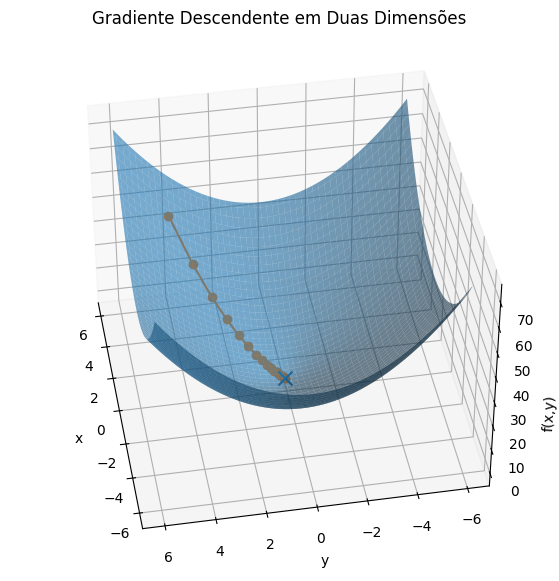

In [31]:
## -- Seu código começa AQUI -- ##
## -- Seu código começa AQUI -- ##

# Cria uma grade de pontos
x_values = np.linspace(-6, 6, 100)
y_values = np.linspace(-6, 6, 100)

X_grid, Y_grid = np.meshgrid(x_values, y_values)

# Calcula a função em cada ponto
Z = X_grid**2 + Y_grid**2

# Converte o histórico
history = np.array(history)

# Cria o gráfico 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Plota a superfície
ax.plot_surface(
    X_grid, Y_grid, Z, alpha=0.6
)

# Calcula os valores de f(x,y) dos pontos percorridos
Z_history = history[:, 0]**2 + history[:, 1]**2

# Plota o caminho do gradiente descendente
ax.plot(
    history[:, 0],
    history[:, 1],
    Z_history,
    marker="o",
    label="Caminho"
)

# Destaca o ponto final
ax.scatter(
    x.item(),
    y.item(),
    (x**2 + y**2).item(),
    marker="x",
    s=100,
    label="Ponto final"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

ax.set_title("Gradiente Descendente em Duas Dimensões")

ax.view_init(elev=40, azim=170)

plt.show()

## -- Seu código termina AQUI -- ##

# Comentários:

# 1. Sim. O algoritmo conseguiu chegar próximo do mínimo nos dois casos.
#    Na função f(x) = x², o mínimo ocorre em x = 0.
#    Na função f(x,y) = x² + y², o mínimo ocorre em (0,0).

# 2. Quando a taxa de aprendizado é muito pequena, os passos realizados
#    pelo algoritmo são pequenos, fazendo com que o treinamento seja
#    mais lento e precise de mais iterações para chegar próximo do mínimo.

# 3. Quando a taxa de aprendizado é muito grande, os passos podem ser
#    muito grandes, fazendo com que o algoritmo passe pelo mínimo,
#    oscile ou até se afaste do ponto de mínimo.

# 4. Esse processo está relacionado ao treinamento de redes neurais,
#    pois os pesos da rede são atualizados utilizando o gradiente
#    descendente para minimizar uma função de perda. A diferenciação
#    automática permite calcular os gradientes necessários para essas
#    atualizações.